#### Linear Regression

In linear regression models, the target value is modeled as a linear combination of the features. The model is trained on a dataset with known target values. The model can then be used to predict the target value for new data points.

The linear regression model is defined as:

$$y = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n$$

where $y$ is the target value, $x_1$ to $x_n$ are the feature values, and $w_0$ to $w_n$ are the model parameters. The model parameters are learned during the training process using the least squares method.

The linear regression model can be extended to include non-linear features by using a non-linear transformation of the features. For example, the model can be extended to include quadratic features as follows:

$$y = w_0 + w_1x_1 + w_2x_2 + w_3x_1^2 + w_4x_2^2$$

The linear regression model can also be extended to include interaction features as follows:

$$y = w_0 + w_1x_1 + w_2x_2 + w_3x_1x_2$$

The linear regression model can be extended to include polynomial features and interaction features at the same time as follows:

$$y = w_0 + w_1x_1 + w_2x_2 + w_3x_1^2 + w_4x_2^2 + w_5x_1x_2$$


We will begin with the simplest linear regression model, with no polynomial or interaction features.

We will use ordinary least squares from the `statsmodels` package. Unlike Scikit-learn's `LinearRegression`, `statsmodels.OLS` does **not** automatically include an intercept. We therefore add a constant column explicitly so that the fitted model is

$$y = w_0 + w_1x.$$

For the data, we will use a Pandas DataFrame with one feature column and one target column.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

df = pd.DataFrame({'x': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                   'y': [1.1, 2.1, 2.9, 3.9, 5.1, 5.9, 6.9, 8.05, 9.1, 9.7]})

print(df)

y = df['y']
X = sm.add_constant(df[['x']])
print()
print("Design matrix (including the intercept column):")
print(X.head())

    x     y
0   1  1.10
1   2  2.10
2   3  2.90
3   4  3.90
4   5  5.10
5   6  5.90
6   7  6.90
7   8  8.05
8   9  9.10
9  10  9.70

Design matrix (including the intercept column):
   const  x
0    1.0  1
1    1.0  2
2    1.0  3
3    1.0  4
4    1.0  5


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     4605.
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           2.47e-12
Time:                        12:45:30   Log-Likelihood:                 7.2239
No. Observations:                  10   AIC:                            -10.45
Df Residuals:                       8   BIC:                            -9.843
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0767      0.090      0.854      0.4

/Users/brash/.pyenv/versions/3.12.7/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


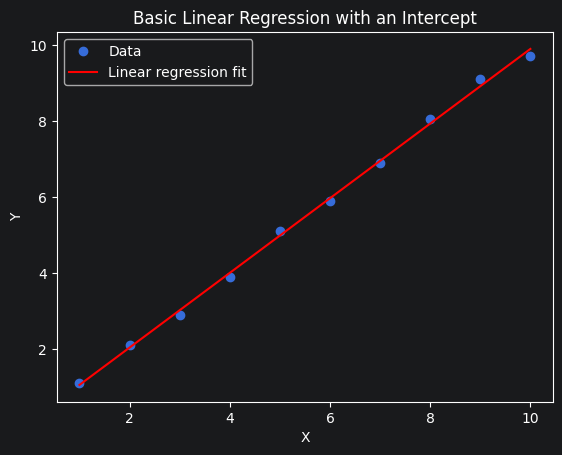

In [3]:
# Ordinary least-squares model from statsmodels
model = sm.OLS(y, X).fit()

# View the coefficient estimates, their uncertainties, and fit diagnostics
print(model.summary())

# Create predictions at the measured x values
y_pred = model.predict(X)

plt.plot(df['x'], y, 'o', label='Data')
plt.plot(df['x'], y_pred, 'r-', label='Linear regression fit')
plt.title("Basic Linear Regression with an Intercept")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()